In [90]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [91]:
df = pd.read_csv(
    "mymoviedb.csv",
    engine='python',
    quoting=1,
    on_bad_lines='skip'
)

In [92]:
df.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [93]:
df.columns

Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='object')

In [94]:
df.shape

(9837, 9)

In [95]:
df.columns.dtype

dtype('O')

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   object 
 1   Title              9828 non-null   object 
 2   Overview           9828 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   object 
 7   Genre              9826 non-null   object 
 8   Poster_Url         9826 non-null   object 
dtypes: float64(1), object(8)
memory usage: 691.8+ KB


In [97]:
df['Genre'].head()

0    Action, Adventure, Science Fiction
1              Crime, Mystery, Thriller
2                              Thriller
3    Animation, Comedy, Family, Fantasy
4      Action, Adventure, Thriller, War
Name: Genre, dtype: object

In [98]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9832    False
9833    False
9834    False
9835    False
9836    False
Length: 9837, dtype: bool

In [99]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


In [100]:
df.duplicated().sum()

0

Exploration Summary

*We have a dataframe consisting of 9827 rows and 9 columns
*Our dataset looks a bit tidy with Nans nor duplicated values
*Release_date column needs to be casted into daste time and to extract only the year value
*Overview,Original_Language and Poster_Url wouldn't be so useful during analysis ,so we'll drop them
*There is noticeable outliers in popularity columns
*Vote_Average better be categorized for proper analysis 
*Genre column has comma speperated values and space that is needed to be consider

In [101]:
df['Release_Date'].dtype

dtype('O')

In [102]:
df['Release_Date'] = pd.to_datetime(df['Release_Date'], errors='coerce')

In [103]:
df['Release_Date'].head(10)

0   2021-12-15
1   2022-03-01
2   2022-02-25
3   2021-11-24
4   2021-12-22
5   2022-01-07
6   2022-01-12
7   2022-02-10
8   2022-02-17
9   2021-11-03
Name: Release_Date, dtype: datetime64[ns]

In [104]:
df['Year'] = df['Release_Date'].dt.year.astype('Int64')

In [105]:
df[['Release_Date', 'Year']].head()

,Release_Date,Year
0,2021-12-15,2021
1,2022-03-01,2022
2,2022-02-25,2022
3,2021-11-24,2021
4,2021-12-22,2021


In [106]:
print(df.head())

  Release_Date                    Title   
0   2021-12-15  Spider-Man: No Way Home  \
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count   
0  Peter Parker is unmasked and no longer able to...    5083.954       8940  \
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre   
0          8.3                en  Action, Adventure, Science Fiction  \
1          8.1                en            Crime, Mystery, Thriller   
2          6.3                en                  

In [107]:
#dropping the columns

In [108]:
cols=['Overview','Original_Language','Poster_Url']

In [109]:
df.drop(cols,axis=1,inplace=True)

In [110]:
print(df)

     Release_Date                                 Title  Popularity   
0      2021-12-15               Spider-Man: No Way Home    5083.954  \
1      2022-03-01                            The Batman    3827.658   
2      2022-02-25                               No Exit    2618.087   
3      2021-11-24                               Encanto    2402.201   
4      2021-12-22                        The King's Man    1895.511   
...           ...                                   ...         ...   
9832   1973-10-15                              Badlands      13.357   
9833   2020-10-01                      Violent Delights      13.356   
9834   2016-05-06                          The Offering      13.355   
9835   2021-03-31  The United States vs. Billie Holiday      13.354   
9836   1984-09-23                               Threads      13.354   

     Vote_Count Vote_Average                               Genre  Year  
0          8940          8.3  Action, Adventure, Science Fiction  2021  
1

categorizing vote_average column

In [111]:
def categorize_col(df, col, labels):
    edges = [
        df[col].min(),
        df[col].quantile(0.25),
        df[col].quantile(0.50),
        df[col].quantile(0.75),
        df[col].max()
    ]
    
    df[col] = pd.cut(df[col], bins=edges, labels=labels, duplicates='drop')
    return df

In [112]:
df['Vote_Average'] = pd.to_numeric(df['Vote_Average'], errors='coerce')

In [113]:
labels=['not_popular','below_avg','avg','popular']

categorize_col(df,'Vote_Average',labels)
df['Vote_Average'].unique()

['popular', 'below_avg', 'avg', 'not_popular', NaN]
Categories (4, object): ['not_popular' < 'below_avg' < 'avg' < 'popular']

In [114]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction",2021
1,2022-03-01,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller",2022
2,2022-02-25,No Exit,2618.087,122,below_avg,Thriller,2022
3,2021-11-24,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy",2021
4,2021-12-22,The King's Man,1895.511,1793,avg,"Action, Adventure, Thriller, War",2021


In [115]:
df['Vote_Average'].value_counts()

Vote_Average
not_popular    2467
popular        2450
avg            2411
below_avg      2398
Name: count, dtype: int64

In [116]:
df.dropna(inplace=True)
df.isna().sum()

Release_Date    0
Title           0
Popularity      0
Vote_Count      0
Vote_Average    0
Genre           0
Year            0
dtype: int64

In [117]:
#change genre , remove white space and explode in dataframe

In [118]:
df['Genre'] = df['Genre'].astype(str).str.split(", ")
df = df.explode('Genre').reset_index(drop=True)

In [119]:
df.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre,Year
0,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,2021-12-15,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,2022-03-01,The Batman,3827.658,1151,popular,Crime,2022
4,2022-03-01,The Batman,3827.658,1151,popular,Mystery,2022


In [120]:
#casting genre column into category

In [122]:
df['Genre']=df['Genre'].astype('category')

In [123]:
df.shape

(25551, 7)

In [124]:
df.nunique()

Release_Date    5845
Title           9414
Popularity      8087
Vote_Count      3265
Vote_Average       4
Genre             19
Year             100
dtype: int64

In [127]:
df = df.drop('Release_Date', axis=1)

In [128]:
df.head()

,Title,Popularity,Vote_Count,Vote_Average,Genre,Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021
3,The Batman,3827.658,1151,popular,Crime,2022
4,The Batman,3827.658,1151,popular,Mystery,2022


** VISUALIZATION**

In [129]:
sns.set_style('whitegrid')

In [130]:
df['Genre'].describe()

count     25551
unique       19
top       Drama
freq       3715
Name: Genre, dtype: object

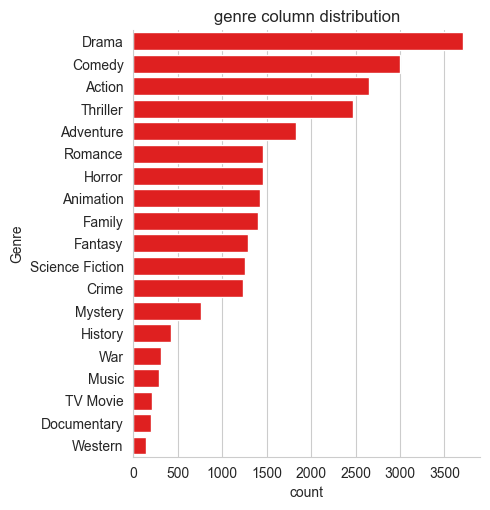

In [131]:
sns.catplot(y='Genre',data=df,kind='count',order=df['Genre'].value_counts().index,color='red')
plt.title('genre column distribution')
plt.show()

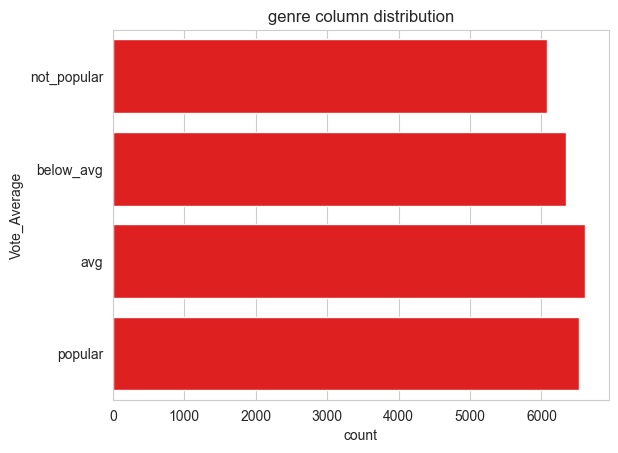

In [132]:
sns.countplot(y='Vote_Average',data=df,color='red')
plt.title('genre column distribution')
plt.show()

In [135]:
#max populairty
df[df['Popularity']==df['Popularity'].max()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Year
0,Spider-Man: No Way Home,5083.954,8940,popular,Action,2021
1,Spider-Man: No Way Home,5083.954,8940,popular,Adventure,2021
2,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction,2021


In [136]:
#min popularity
df[df['Popularity']==df['Popularity'].min()]

,Title,Popularity,Vote_Count,Vote_Average,Genre,Year
25545,The United States vs. Billie Holiday,13.354,152,avg,Music,2021
25546,The United States vs. Billie Holiday,13.354,152,avg,Drama,2021
25547,The United States vs. Billie Holiday,13.354,152,avg,History,2021
25548,Threads,13.354,186,popular,War,1984
25549,Threads,13.354,186,popular,Drama,1984
25550,Threads,13.354,186,popular,Science Fiction,1984


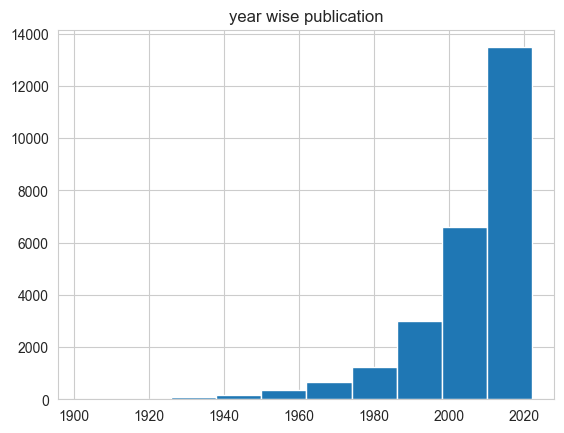

In [139]:
df['Year'].hist()
plt.title('year wise publication')
plt.show()

## SUMMARY

q1: what is the most frequent genre in the datset?
Drama genre is the most frequent genre in our datset and has appeared more then 14 % of the times among 19 other genres

q2: what genre has highest votes?
we have 25.5% of our datset with popular vote ,drame again gets the highest popularity

q3: what movie gets the highest and lowest popularity? and what is the genre ?
spider man has the highest populairty with the genre of action,adventure and science fiction while the lowest is with united stes , thread having genre of music ,drama,scifi

q4: Which year has most filmed movies?
year 2020